# Wave Packet Ray Tracing in Cylindrical Vortex (Full WKB Dispersion Relation)

## Physical Setup

- **Lamb-Oseen vortex**: $V_\theta(r) = V_{\text{max}} \frac{1 - e^{-r^2/r_c^2}}{r}$
- **Vortex angular velocity**: $\bar{\Omega}(r) = V_\theta(r)/r$
- **Vertical vorticity**: $\zeta(r) = \frac{1}{r}\frac{d(rV_\theta)}{dr}$
- **Background rotation rate**: $\Omega$ (constant, e.g., planetary rotation)
- **Brunt-Väisälä frequency**: $N$ (background stratification)

## Full WKB Dispersion Relation

The **complete** WKB dispersion relation for inertia-gravity waves in a rotating, stratified, sheared vortex is:

$$
D(k_r, r) = k_r^2 \Phi - k_r \left(m \frac{d\bar{\Omega}}{dr}\right) + \Phi \left[ \frac{m^2}{r^2} + \frac{\Phi^2 + \Delta(r)}{\Phi^2 + N^2} k_z^2 \right] = 0
$$

where:
- $\Phi = \sigma + im\bar{\Omega}(r)$ is the **complex** Doppler-shifted frequency
- For quasi-stationary waves: $\sigma = 0$, so $\Phi = im\bar{\Omega}(r)$ (purely imaginary)
- $\Delta(r) = 2(\zeta + 2\Omega)(\bar{\Omega} + \Omega)$ is the effective vorticity
- $k_z$ is the vertical wavenumber (fixed)
- $m$ is the azimuthal mode number

### Key Differences from Simplified Model:

1. **Complex wavenumber**: $k_r = k_R + ik_I$ (both real and imaginary parts)
2. **Shear term**: $k_r \left(m \frac{d\bar{\Omega}}{dr}\right)$ cannot be neglected
3. **Curvature term**: $\frac{m^2}{r^2}$ must be retained

## Ray Path from Group Velocity

The ray trajectory is determined by the complex group velocity:

$$
\frac{dz}{dr} = \text{Re}\left[\frac{\partial D/\partial k_z}{\partial D/\partial k_r}\right]
$$

where:
- $C_z = \frac{\partial D}{\partial k_z} = 2k_z \Phi \frac{\Phi^2 + \Delta}{\Phi^2 + N^2}$
- $C_r = \frac{\partial D}{\partial k_r} = 2k_r \Phi - m\frac{d\bar{\Omega}}{dr}$

## Wave Amplitude and Critical Layers

- **Wave amplitude**: $A \propto \exp\left(-\int k_I(r) dr\right)$
  - $k_I < 0$: Wave growth (red in plots)
  - $k_I > 0$: Wave decay (blue in plots)
- **Critical layer** (for stationary waves, $\sigma = 0$): Where $|m\bar{\Omega}(r)| = N$
  - This is where the Doppler-shifted frequency equals the buoyancy frequency
  - Wave properties change dramatically near critical layers

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.colors import TwoSlopeNorm
import numpy.lib.scimath as scimath
import warnings
warnings.filterwarnings('ignore')

## 1. Background Vortex Profile

In [13]:
class GeneralVortex:
    """
    General vortex profile given:
    - Omega_bar(r): angular velocity profile
    - dOmega_bar_dr(r): radial derivative of angular velocity
    - Omega_bg: background rotation rate (constant)
    
    All other quantities are calculated automatically:
    - V_theta(r) = r * Omega_bar(r): azimuthal velocity
    - zeta(r) = 2*Omega_bar + r*dOmega_bar/dr: axial vorticity
    - Delta(r) = 2*(zeta + 2*Omega_bg)*(Omega_bar + Omega_bg): Rayleigh discriminant
    """
    
    def __init__(self, Omega_bar_func, dOmega_bar_dr_func, Omega_bg: float):
        """
        Parameters:
        -----------
        Omega_bar_func : callable
            Function that returns angular velocity Omega_bar(r)
            Should handle r=0 appropriately (e.g., return 0 or limit value)
        dOmega_bar_dr_func : callable
            Function that returns dOmega_bar/dr at radius r
            Should handle r=0 appropriately (e.g., return 0 or limit value)
        Omega_bg : float
            Background rotation rate (constant, like planetary rotation)
        """
        self.Omega_bar_func = Omega_bar_func
        self.dOmega_bar_dr_func = dOmega_bar_dr_func
        self.Omega_bg = float(Omega_bg)
        
    def Omega_bar(self, r):
        """Vortex angular velocity"""
        r_input = r
        r = np.atleast_1d(np.asarray(r, dtype=float))
        
        Omega_bar_val = np.zeros_like(r, dtype=float)
        mask = r > 1e-10
        # For r > 0, use the provided function
        Omega_bar_val[mask] = self.Omega_bar_func(r[mask])
        # For r ≈ 0, assume function handles it or returns 0
        Omega_bar_val[~mask] = self.Omega_bar_func(np.array([1e-10]))[0] if np.any(~mask) else 0.0
        
        if np.ndim(r_input) == 0:
            return float(Omega_bar_val[0])
        return Omega_bar_val
    
    def dOmega_bar_dr(self, r):
        """Radial derivative of angular velocity"""
        r_input = r
        r = np.atleast_1d(np.asarray(r, dtype=float))
        
        dOmega = np.zeros_like(r, dtype=float)
        mask = r > 1e-10
        # For r > 0, use the provided function
        dOmega[mask] = self.dOmega_bar_dr_func(r[mask])
        # For r ≈ 0, assume function handles it or returns 0
        dOmega[~mask] = self.dOmega_bar_dr_func(np.array([1e-10]))[0] if np.any(~mask) else 0.0
        
        if np.ndim(r_input) == 0:
            return float(dOmega[0])
        return dOmega
    
    def V_theta(self, r):
        """Azimuthal velocity: V_theta = r * Omega_bar(r)"""
        r_input = r
        r = np.atleast_1d(np.asarray(r, dtype=float))
        
        V = np.zeros_like(r, dtype=float)
        mask = r > 1e-10
        V[mask] = r[mask] * self.Omega_bar(r[mask])
        
        if np.ndim(r_input) == 0:
            return float(V[0])
        return V

    def zeta(self, r):
        """
        Vertical vorticity: zeta = (1/r) * d(r*V_theta)/dr
        Using V_theta = r * Omega_bar:
        zeta = (1/r) * d(r^2 * Omega_bar)/dr
            = (1/r) * (2*r*Omega_bar + r^2*dOmega_bar/dr)
            = 2*Omega_bar + r*dOmega_bar/dr
        """
        r_input = r
        r = np.atleast_1d(np.asarray(r, dtype=float))
        
        Omega_bar_val = self.Omega_bar(r)
        dOmega_dr = self.dOmega_bar_dr(r)
        
        zeta_val = 2 * Omega_bar_val + r * dOmega_dr

        if np.ndim(r_input) == 0:
            return float(zeta_val[0]) if np.ndim(zeta_val) == 0 else float(zeta_val.item())
        return zeta_val
    
    def Delta(self, r, Omega_bg: float = None):
        """
        Rayleigh discriminant: Delta = 2*(zeta + 2*Omega_bg)*(Omega_bar + Omega_bg)
        """
        if Omega_bg is None:
            Omega_bg = self.Omega_bg
        else:
            Omega_bg = float(Omega_bg)
        
        r_input = r    
        zeta_val = self.zeta(r)
        Omega_bar_val = self.Omega_bar(r)
        
        result = 2 * (zeta_val + 2 * Omega_bg) * (Omega_bar_val + Omega_bg)
        
        if np.ndim(r_input) == 0:
            if np.ndim(result) == 0:
                return float(result)
            else:
                return float(result.item()) if result.size == 1 else result
        return result

## 2. Full WKB Dispersion Relation and Ray Tracing

In [14]:
class FullWKBRayTracer:
    """
    Ray tracing using the full WKB dispersion relation with complex wavenumbers.
    
    Dispersion relation:
    D = kr^2 * Phi - kr * (m * dOmega_bar/dr) + Phi * [m^2/r^2 + ((Phi^2 + Delta)/(Phi^2 + N^2)) * kz^2] = 0
    
    Ray path:
    dz/dr = Re[C_z / C_r]
    where C_z = dD/dkz, C_r = dD/dkr
    """
    
    def __init__(self, vortex, N: float, m: int, kz: float, 
                 sigma: complex = 0.0, r_min: float = 5.0, r_max: float = 50.0):
        """
        Parameters:
        -----------
        vortex : GeneralVortex or LambOseenVortex
            Background vortex profile
        N : float
            Brunt-Väisälä frequency
        m : int
            Azimuthal mode number
        kz : float
            Vertical wavenumber (fixed)
        sigma : complex
            Wave frequency (0 for quasi-stationary waves, can be complex)
        r_min : float
            Minimum radial extent
        r_max : float
            Maximum radial extent
        """
        self.vortex = vortex
        self.N = float(N)
        self.m = int(m)
        self.kz = float(kz)
        self.sigma = complex(sigma)
        self.r_min = float(r_min)
        self.r_max = float(r_max)
        self.Omega_bg = vortex.Omega_bg
        
        # Validate sigma: must be zero or purely imaginary (no growing modes)
        if abs(np.real(self.sigma)) > 1e-10:
            raise ValueError(f"sigma must be zero or purely imaginary (no real part). Got sigma = {self.sigma}")
        
        print(f"Full WKB Ray Tracer Initialized:")
        print(f"  Omega_bg = {self.Omega_bg:.4f}")
        print(f"  N = {N:.4f}")
        print(f"  m = {m}, kz = {kz:.4f}")
        if np.imag(sigma) == 0:
            print(f"  sigma = {np.real(sigma):.4f}")
        else:
            print(f"  sigma = {np.imag(sigma):.4f}i")
        print(f"  r_min = {r_min:.4f}, r_max = {r_max:.4f}")
    
    def compute_Phi(self, r: float) -> complex:
        """Compute complex Doppler-shifted frequency: Phi = sigma + i*m*Omega_bar(r)"""
        r = float(r)
        Omega_bar_r = self.vortex.Omega_bar(r)
        return self.sigma + 1j * self.m * Omega_bar_r
    
    def solve_kr(self, r: float):
        """
        Solve the full WKB dispersion relation for complex kr at radius r.
        
        Quadratic equation: A*kr^2 + B*kr + C = 0
        where:
            A = Phi
            B = -m * dOmega_bar/dr
            C = Phi * [m^2/r^2 + ((Phi^2 + Delta)/(Phi^2 + N^2)) * kz^2]
        
        Returns both branches of the square root.
        """
        r = float(r)
        
        # Complex Doppler-shifted frequency
        Phi = self.compute_Phi(r)
        
        # Shear term
        dOmega_dr = self.vortex.dOmega_bar_dr(r)
        
        # Rayleigh discriminant
        Delta = self.vortex.Delta(r)
        
        # Coefficients of the quadratic equation
        A = Phi
        B = -self.m * dOmega_dr
        C = Phi * (self.m**2 / r**2 + ((Phi**2 + Delta) / (Phi**2 + self.N**2)) * self.kz**2)
        
        # Solve quadratic using complex square root
        discriminant = B**2 - 4*A*C
        sqrt_discriminant = scimath.sqrt(discriminant)
        
        kr_1 = (-B + sqrt_discriminant) / (2 * A)
        kr_2 = (-B - sqrt_discriminant) / (2 * A)
        
        return kr_1, kr_2
    
    def compute_ray_slope(self, r: float, kr: complex) -> float:
        """
        Compute dz/dr = Re[C_z / C_r]
        
        C_z = dD/dkz = 2*kz*Phi * [(Phi^2 + Delta)/(Phi^2 + N^2)]
        C_r = dD/dkr = 2*kr*Phi - m*dOmega_bar/dr
        """
        r = float(r)
        
        Phi = self.compute_Phi(r)
        Delta = self.vortex.Delta(r)
        dOmega_dr = self.vortex.dOmega_bar_dr(r)
        
        # Group velocity components
        C_z = 2 * self.kz * Phi * ((Phi**2 + Delta) / (Phi**2 + self.N**2))
        C_r = 2 * kr * Phi - self.m * dOmega_dr
        
        # Ray slope is the real part of C_z / C_r
        slope_complex = C_z / C_r
        slope = np.real(slope_complex)
        
        return slope
    
    def find_critical_layers(self, r_min: float = None, r_max: float = None, 
                            n_scan: int = 1000) -> dict:
        """
        Find critical layer locations where Phi = 0 or |Phi|^2 = N^2.
        
        Baroclinic critical layer: |m*Omega_bar(r) + sigma/i|^2 = N^2
        Barotropic critical layer: m*Omega_bar(r) + sigma/i = 0
        
        Returns:
        --------
        dict with keys 'baroclinic' and 'barotropic', each containing list of r values
        """
        if r_min is None:
            r_min = self.r_min
        if r_max is None:
            r_max = self.r_max
        
        r_scan = np.linspace(r_min, r_max, n_scan)
        
        baroclinic_layers = []
        barotropic_layers = []
        
        for i in range(len(r_scan) - 1):
            r1, r2 = r_scan[i], r_scan[i+1]
            
            # Compute |Phi|^2 at both points
            Phi1 = self.compute_Phi(r1)
            Phi2 = self.compute_Phi(r2)
            
            Phi1_sq = np.abs(Phi1)**2
            Phi2_sq = np.abs(Phi2)**2
            
            # Check for baroclinic critical layer: |Phi|^2 crosses N^2
            if (Phi1_sq - self.N**2) * (Phi2_sq - self.N**2) < 0:
                # Refine with bisection
                from scipy.optimize import brentq
                try:
                    def func_baroclinic(r):
                        return np.abs(self.compute_Phi(r))**2 - self.N**2
                    r_crit = brentq(func_baroclinic, r1, r2, xtol=1e-6)
                    baroclinic_layers.append(r_crit)
                except:
                    pass
            
            # Check for barotropic critical layer: Phi crosses 0
            # For purely imaginary sigma, Phi = i*(m*Omega_bar + Im(sigma))
            # So we check when m*Omega_bar + Im(sigma) crosses 0
            if np.imag(self.sigma) != 0:
                omega1 = self.m * self.vortex.Omega_bar(r1) + np.imag(self.sigma)
                omega2 = self.m * self.vortex.Omega_bar(r2) + np.imag(self.sigma)
                
                if omega1 * omega2 < 0:
                    from scipy.optimize import brentq
                    try:
                        def func_barotropic(r):
                            return self.m * self.vortex.Omega_bar(r) + np.imag(self.sigma)
                        r_crit = brentq(func_barotropic, r1, r2, xtol=1e-6)
                        barotropic_layers.append(r_crit)
                    except:
                        pass
        
        return {
            'baroclinic': baroclinic_layers,
            'barotropic': barotropic_layers
        }
    
    def trace_ray(self, r0: float, z0: float, kr_branch: int = 1,
                  r_min: float = None, r_max: float = None,
                  critical_layers: dict = None, buffer: float = 0.05):
        """
        Trace a ray path with memory-resetting at critical layers.
        
        PIECEWISE TRACING ALGORITHM:
        1. Identify all critical layer locations in [r_min, r_max]
        2. Divide domain into segments separated by critical layers
        3. In each segment, integrate ODE from midpoint in both directions
        4. Combine all segments into a single path
        
        Parameters:
        -----------
        r0, z0 : float
            Starting position
        kr_branch : int (1 or 2)
            Which branch of kr to trace
        r_min, r_max : float
            Domain boundaries (uses self.r_min, self.r_max if None)
        critical_layers : dict or None
            Pre-computed critical layers {'baroclinic': [...], 'barotropic': [...]}
            If None, will compute automatically
        buffer : float
            Distance to stay away from critical layer boundaries
        
        Returns:
        --------
        r_path, z_path, kI_path : arrays
            Ray trajectory and imaginary wavenumber along the path
        """
        if r_min is None:
            r_min = self.r_min
        if r_max is None:
            r_max = self.r_max
        
        # Find critical layers if not provided
        if critical_layers is None:
            critical_layers = self.find_critical_layers(r_min, r_max)
        
        # Collect all critical layer radii
        all_crit_radii = []
        all_crit_radii.extend(critical_layers.get('baroclinic', []))
        all_crit_radii.extend(critical_layers.get('barotropic', []))
        all_crit_radii.sort()
        
        # Create segment boundaries (buffer around each critical layer)
        segment_boundaries = [r_min]
        for rc in all_crit_radii:
            if rc - buffer > segment_boundaries[-1]:
                segment_boundaries.append(rc - buffer)
            segment_boundaries.append(rc + buffer)
        segment_boundaries.append(r_max)
        
        # Remove duplicates and sort
        segment_boundaries = sorted(list(set(segment_boundaries)))
        
        # Find which segment contains r0
        segment_idx = None
        for i in range(len(segment_boundaries) - 1):
            if segment_boundaries[i] <= r0 <= segment_boundaries[i+1]:
                segment_idx = i
                break
        
        if segment_idx is None:
            raise ValueError(f"Starting position r0={r0} is outside domain [{r_min}, {r_max}]")
        
        # Define ODE function
        def ode_func(r, z):
            kr_1, kr_2 = self.solve_kr(r)
            kr = kr_1 if kr_branch == 1 else kr_2
            dzdr = self.compute_ray_slope(r, kr)
            return dzdr
        
        # Trace all segments
        all_segments = []
        
        for i in range(len(segment_boundaries) - 1):
            r_left = segment_boundaries[i]
            r_right = segment_boundaries[i+1]
            r_mid = (r_left + r_right) / 2
            
            # Determine initial z for this segment
            if i == segment_idx:
                # This is the segment containing the starting point
                z_init = z0
                r_init = r0
            else:
                # Skip segments far from starting point for now
                continue
            
            # Trace inward from r_init to r_left
            if r_init > r_left + 1e-6:
                sol_in = solve_ivp(ode_func, [r_init, r_left], [z_init],
                                  dense_output=True, max_step=0.1,
                                  rtol=1e-6, atol=1e-8)
                r_in = sol_in.t
                z_in = sol_in.y[0]
            else:
                r_in = np.array([])
                z_in = np.array([])
            
            # Trace outward from r_init to r_right
            if r_init < r_right - 1e-6:
                sol_out = solve_ivp(ode_func, [r_init, r_right], [z_init],
                                   dense_output=True, max_step=0.1,
                                   rtol=1e-6, atol=1e-8)
                r_out = sol_out.t
                z_out = sol_out.y[0]
            else:
                r_out = np.array([])
                z_out = np.array([])
            
            # Combine: inward (reversed) + outward
            r_seg = np.concatenate([r_in[::-1], r_out[1:]])  # Skip duplicate at r_mid
            z_seg = np.concatenate([z_in[::-1], z_out[1:]])
            
            # Compute kI for this segment
            kI_seg = []
            for r_val in r_seg:
                kr_1, kr_2 = self.solve_kr(r_val)
                kr = kr_1 if kr_branch == 1 else kr_2
                kI_seg.append(np.imag(kr))
            kI_seg = np.array(kI_seg)
            
            all_segments.append((r_seg, z_seg, kI_seg))
        
        # Combine all segments and sort by r
        r_all = np.concatenate([seg[0] for seg in all_segments])
        z_all = np.concatenate([seg[1] for seg in all_segments])
        kI_all = np.concatenate([seg[2] for seg in all_segments])
        
        # Sort by r
        sort_idx = np.argsort(r_all)
        r_sorted = r_all[sort_idx]
        z_sorted = z_all[sort_idx]
        kI_sorted = kI_all[sort_idx]
        
        return r_sorted, z_sorted, kI_sorted

# Part I: Stationary Waves (σ = 0)

This section analyzes stationary waves with σ = 0, where only baroclinic critical layers exist.

## 3. Setup Parameters and Visualize Background Vortex

In [4]:
# Define Keplerian rotation profile: Omega ~ r^(-3/2)
# To avoid singularity at r=0, we use: Omega_bar(r) = Omega_0 * (r + r_smooth)^(-3/2)

# Physical parameters
Omega_0 = 1.0  # Normalization constant
r_smooth = 0.0001  # Smoothing radius to avoid singularity at r=0
Omega_bg = 0.0  # No background rotation
N = 0.08  # Brunt-Väisälä frequency

# Define the Keplerian profile functions
def Omega_bar_keplerian(r):
    """Keplerian angular velocity: Omega ~ r^(-3/2) with smoothing"""
    r = np.atleast_1d(np.asarray(r, dtype=float))
    result = Omega_0 * np.power(r + r_smooth, -1.5)
    return result if result.shape != (1,) else float(result[0])

def dOmega_bar_dr_keplerian(r):
    """Derivative of Keplerian angular velocity"""
    r = np.atleast_1d(np.asarray(r, dtype=float))
    result = -1.5 * Omega_0 * np.power(r + r_smooth, -2.5)
    return result if result.shape != (1,) else float(result[0])

# Create GeneralVortex with Keplerian profile
vortex = GeneralVortex(Omega_bar_keplerian, dOmega_bar_dr_keplerian, Omega_bg)

print(f"\nPhysical parameters (Keplerian profile):")
print(f"  Omega_0 = {Omega_0} (normalization)")
print(f"  r_smooth = {r_smooth} (smoothing radius)")
print(f"  Profile: Omega(r) = {Omega_0} * (r + {r_smooth})^(-3/2)")
print(f"  Omega_bg = {Omega_bg}")
print(f"  N = {N}")


Physical parameters (Keplerian profile):
  Omega_0 = 1.0 (normalization)
  r_smooth = 0.0001 (smoothing radius)
  Profile: Omega(r) = 1.0 * (r + 0.0001)^(-3/2)
  Omega_bg = 0.0
  N = 0.08


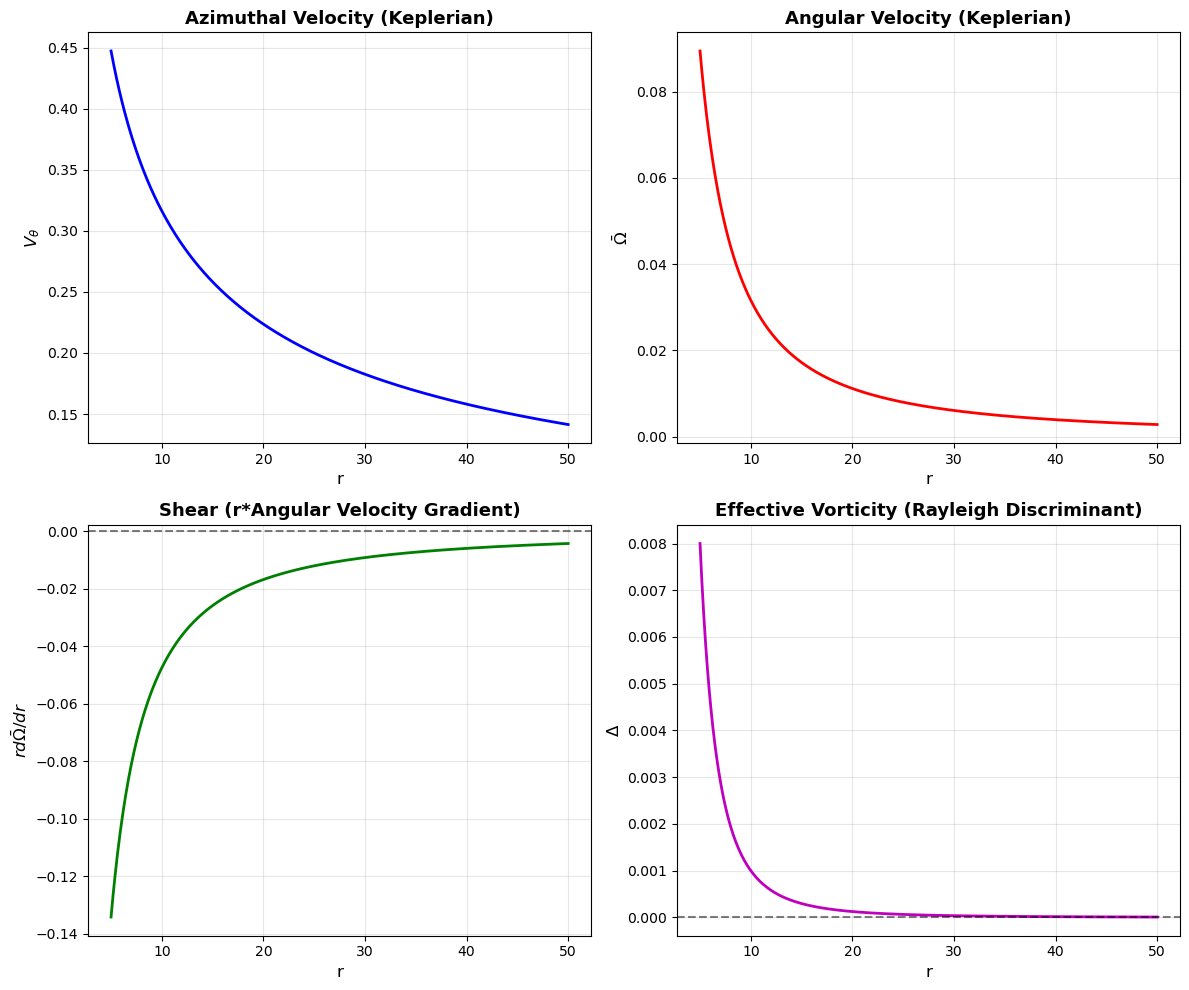

In [5]:
# Visualize Keplerian vortex profiles
r_plot = np.linspace(5, 50, 500)

# Visualize profiles
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# V_theta
axes[0,0].plot(r_plot, vortex.V_theta(r_plot), 'b-', linewidth=2)
axes[0,0].set_xlabel('r', fontsize=12)
axes[0,0].set_ylabel('$V_\\theta$', fontsize=12)
axes[0,0].set_title('Azimuthal Velocity (Keplerian)', fontsize=13, fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# Omega_bar
axes[0,1].plot(r_plot, vortex.Omega_bar(r_plot), 'r-', linewidth=2)
axes[0,1].set_xlabel('r', fontsize=12)
axes[0,1].set_ylabel('$\\bar{\\Omega}$', fontsize=12)
axes[0,1].set_title('Angular Velocity (Keplerian)', fontsize=13, fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# dOmega_bar/dr
axes[1,0].plot(r_plot, r_plot*vortex.dOmega_bar_dr(r_plot), 'g-', linewidth=2)
axes[1,0].set_xlabel('r', fontsize=12)
axes[1,0].set_ylabel('$rd\\bar{\\Omega}/dr$', fontsize=12)
axes[1,0].set_title('Shear (r*Angular Velocity Gradient)', fontsize=13, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].axhline(0, color='k', linestyle='--', alpha=0.5)

# Delta
axes[1,1].plot(r_plot, vortex.Delta(r_plot), 'm-', linewidth=2)
axes[1,1].set_xlabel('r', fontsize=12)
axes[1,1].set_ylabel('$\\Delta$', fontsize=12)
axes[1,1].set_title('Effective Vorticity (Rayleigh Discriminant)', fontsize=13, fontweight='bold')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].axhline(0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 4. Stationary Wave Analysis (σ = 0): Trace Ray Paths

In [6]:
# Wave parameters for stationary waves
m = 2
kz = 1.0
sigma = 0.0  # Stationary wave
r_max_domain = 30

# Initialize ray tracer
tracer_stationary = FullWKBRayTracer(vortex, N, m, kz, sigma, r_max_domain)

# Find critical layers
critical_layers_stationary = tracer_stationary.find_critical_layers()
print(f"\nCritical layers for σ={sigma}:")
print(f"  Baroclinic: {critical_layers_stationary['baroclinic']}")
print(f"  Barotropic: {critical_layers_stationary['barotropic']}")

# For convenience, get the first baroclinic critical layer
r_crit_stationary = critical_layers_stationary['baroclinic'][0] if len(critical_layers_stationary['baroclinic']) > 0 else None

# Starting position (choose a reasonable radius)
r0 = 5.0
z0 = 0.0

print(f"\nStarting position: r0 = {r0:.3f}, z0 = {z0:.3f}")

Full WKB Ray Tracer Initialized:
  Omega_bg = 0.0000
  N = 0.0800
  m = 2, kz = 1.0000
  sigma = 0.0000
  r_min = 30.0000, r_max = 50.0000

Critical layers for σ=0.0:
  Baroclinic: []
  Barotropic: []

Starting position: r0 = 5.000, z0 = 0.000


In [7]:
# Trace both kr branches for stationary wave
print("\nTracing ray paths for stationary wave...")

# Branch 1
r1_stat, z1_stat, kI1_stat = tracer_stationary.trace_ray(r0, z0, kr_branch=1, 
                                                          r_min=0.1, r_max=r_max_domain, 
                                                          critical_layers=critical_layers_stationary)
print(f"Branch 1: {len(r1_stat)} points, r ∈ [{r1_stat.min():.3f}, {r1_stat.max():.3f}], z ∈ [{z1_stat.min():.3f}, {z1_stat.max():.3f}]")
print(f"  kI range: [{kI1_stat.min():.4f}, {kI1_stat.max():.4f}]")

# Branch 2
r2_stat, z2_stat, kI2_stat = tracer_stationary.trace_ray(r0, z0, kr_branch=2,
                                                          r_min=0.1, r_max=r_max_domain, 
                                                          critical_layers=critical_layers_stationary)
print(f"Branch 2: {len(r2_stat)} points, r ∈ [{r2_stat.min():.3f}, {r2_stat.max():.3f}], z ∈ [{z2_stat.min():.3f}, {z2_stat.max():.3f}]")
print(f"  kI range: [{kI2_stat.min():.4f}, {kI2_stat.max():.4f}]")


Tracing ray paths for stationary wave...
Branch 1: 400 points, r ∈ [0.100, 30.000], z ∈ [-10.599, 0.000]
  kI range: [-6653695.7249, 0.0877]
Branch 1: 400 points, r ∈ [0.100, 30.000], z ∈ [-10.599, 0.000]
  kI range: [-6653695.7249, 0.0877]
Branch 2: 400 points, r ∈ [0.100, 30.000], z ∈ [0.000, 10.599]
  kI range: [0.0250, 6653695.9003]
Branch 2: 400 points, r ∈ [0.100, 30.000], z ∈ [0.000, 10.599]
  kI range: [0.0250, 6653695.9003]


scatter1 = plot_ray_segments(ax1, r1_stat, z1_stat, kI1_stat, critical_layers_stationary, 
                             cmap, norm_stat, buffer=0.05)
if r_crit_stationary is not None:
    ax1.axvline(r_crit_stationary, color='purple', linestyle=':', linewidth=2, alpha=0.7,
               label=f'Baroclinic CL (r = {r_crit_stationary:.2f})')
ax1.set_xlabel('Radial position r', fontsize=14, fontweight='bold')
ax1.set_ylabel('Vertical position z', fontsize=14, fontweight='bold')
ax1.set_title(f'Stationary Wave: Branch 1 (m={m}, kz={kz}, σ=0)\nKeplerian Profile', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, r_max_domain)
ax1.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)

# Right panel: Branch 2
ax2 = axes[1]
scatter2 = plot_ray_segments(ax2, r2_stat, z2_stat, kI2_stat, critical_layers_stationary, 
                             cmap, norm_stat, buffer=0.05)
if r_crit_stationary is not None:
    ax2.axvline(r_crit_stationary, color='purple', linestyle=':', linewidth=2, alpha=0.7,
               label=f'Baroclinic CL (r = {r_crit_stationary:.2f})')
ax2.set_xlabel('Radial position r', fontsize=14, fontweight='bold')
ax2.set_ylabel('Vertical position z', fontsize=14, fontweight='bold')
ax2.set_title(f'Stationary Wave: Branch 2 (m={m}, kz={kz}, σ=0)\nKeplerian Profile', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, r_max_domain)
ax2.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
plt.tight_layout()

# Colorbar
cbar = fig.colorbar(scatter2, ax=axes, orientation='horizontal',
                    pad=0.15, aspect=40, shrink=0.8)
cbar.set_label('$k_I$: Red = Growth (negative), Blue = Decay (positive)', 
               fontsize=12, fontweight='bold')

plt.show()

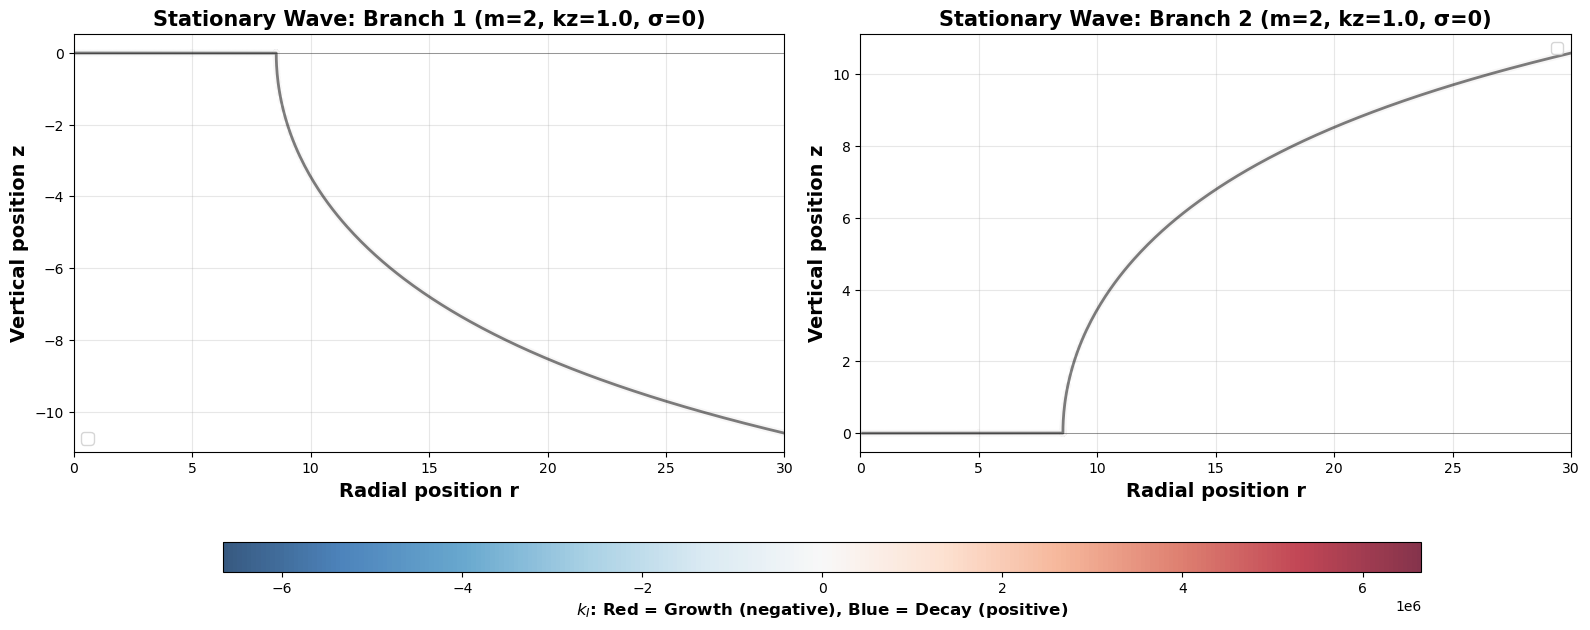

In [10]:
def plot_ray_segments(ax, r_array, z_array, kI_array, critical_layers, cmap, norm, 
                      buffer=0.05, linewidth=2, alpha=0.5):
    """
    Plot ray path in segments, splitting at critical layers to avoid connecting discontinuities.
    
    Parameters:
    -----------
    ax : matplotlib axis
    r_array, z_array, kI_array : arrays of ray path data
    critical_layers : dict with 'baroclinic' and 'barotropic' lists
    buffer : float, buffer around critical layers (should match trace_ray buffer)
    """
    # Collect all critical layer radii
    all_crit_radii = []
    all_crit_radii.extend(critical_layers.get('baroclinic', []))
    all_crit_radii.extend(critical_layers.get('barotropic', []))
    all_crit_radii.sort()
    
    if len(all_crit_radii) == 0:
        # No critical layers, plot entire path
        ax.plot(r_array, z_array, 'k-', linewidth=linewidth, alpha=alpha)
    else:
        # Split ray path into segments based on critical layer locations
        # Each segment is between two critical layers (or domain boundaries)
        boundaries = [r_array.min()]
        for rc in all_crit_radii:
            boundaries.append(rc - buffer)
            boundaries.append(rc + buffer)
        boundaries.append(r_array.max())
        
        # Plot each segment separately
        for i in range(0, len(boundaries)-1, 2 if len(all_crit_radii) > 0 else 1):
            r_left = boundaries[i]
            r_right = boundaries[i+1] if i+1 < len(boundaries) else boundaries[-1]
            
            # Find points in this segment
            mask = (r_array >= r_left) & (r_array <= r_right)
            if np.sum(mask) > 1:  # Need at least 2 points to plot a line
                ax.plot(r_array[mask], z_array[mask], 'k-', linewidth=linewidth, alpha=alpha)
    
    # Plot scatter points on top
    scatter = ax.scatter(r_array, z_array, c=kI_array, cmap=cmap, norm=norm, s=15, alpha=0.8)
    return scatter

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Use linear scale for kI values
# Negative kI (growth) -> RED, Positive kI (decay) -> BLUE
kI_all_stat = np.concatenate([kI1_stat, kI2_stat])

# Symmetric color scale around zero (linear, not log)
kI_max_stat = max(abs(kI_all_stat.min()), abs(kI_all_stat.max()))
norm_stat = TwoSlopeNorm(vmin=-kI_max_stat, vcenter=0, vmax=kI_max_stat)
cmap = plt.cm.RdBu_r  # RdBu_r: Red for negative (growth), Blue for positive (decay)

# Left panel: Branch 1
ax1 = axes[0]
scatter1 = plot_ray_segments(ax1, r1_stat, z1_stat, kI1_stat, critical_layers_stationary, 
                             cmap, norm_stat, buffer=0.05)
if r_crit_stationary is not None:
    ax1.axvline(r_crit_stationary, color='purple', linestyle=':', linewidth=2, alpha=0.7,
               label=f'Baroclinic CL (r = {r_crit_stationary:.2f})')
ax1.set_xlabel('Radial position r', fontsize=14, fontweight='bold')
ax1.set_ylabel('Vertical position z', fontsize=14, fontweight='bold')
ax1.set_title(f'Stationary Wave: Branch 1 (m={m}, kz={kz}, σ=0)', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, r_max_domain)
ax1.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)

# Right panel: Branch 2
ax2 = axes[1]
scatter2 = plot_ray_segments(ax2, r2_stat, z2_stat, kI2_stat, critical_layers_stationary, 
                             cmap, norm_stat, buffer=0.05)
if r_crit_stationary is not None:
    ax2.axvline(r_crit_stationary, color='purple', linestyle=':', linewidth=2, alpha=0.7,
               label=f'Baroclinic CL (r = {r_crit_stationary:.2f})')
ax2.set_xlabel('Radial position r', fontsize=14, fontweight='bold')
ax2.set_ylabel('Vertical position z', fontsize=14, fontweight='bold')
ax2.set_title(f'Stationary Wave: Branch 2 (m={m}, kz={kz}, σ=0)', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, r_max_domain)
ax2.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
plt.tight_layout()

# Colorbar
cbar = fig.colorbar(scatter2, ax=axes, orientation='horizontal',
                    pad=0.15, aspect=40, shrink=0.8)
cbar.set_label('$k_I$: Red = Growth (negative), Blue = Decay (positive)', 
               fontsize=12, fontweight='bold')

plt.show()


## 6. Compare Wavenumber Components

TypeError: '>' not supported between instances of 'float' and 'NoneType'

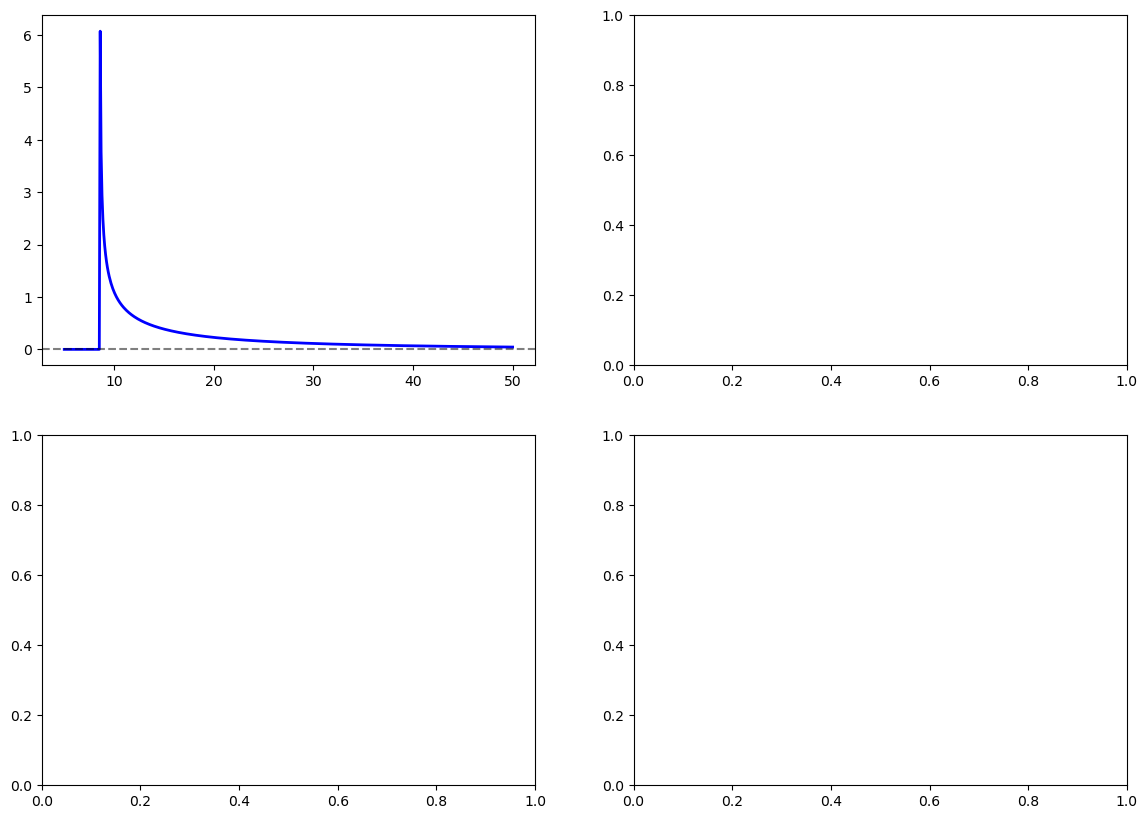

In [11]:
# Compute kr components as function of r
r_scan = np.linspace(5, 50, 500)
kr1_real = []
kr1_imag = []
kr2_real = []
kr2_imag = []

for r in r_scan:
    kr_1, kr_2 = tracer_stationary.solve_kr(r)
    kr1_real.append(np.real(kr_1))
    kr1_imag.append(np.imag(kr_1))
    kr2_real.append(np.real(kr_2))
    kr2_imag.append(np.imag(kr_2))

kr1_real = np.array(kr1_real)
kr1_imag = np.array(kr1_imag)
kr2_real = np.array(kr2_real)
kr2_imag = np.array(kr2_imag)

# Use percentile-based limits to avoid extreme values near singularities
def get_robust_limits(data, lower_percentile=5, upper_percentile=95):
    """Get y-limits based on percentiles to avoid extreme outliers"""
    y_min = np.percentile(data, lower_percentile)
    y_max = np.percentile(data, upper_percentile)
    margin = 0.1 * (y_max - y_min)
    return y_min - margin, y_max + margin

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Real part - Branch 1
axes[0,0].plot(r_scan, kr1_real, 'b-', linewidth=2)
axes[0,0].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[0,0].axvline(r_crit_stationary, color='orange', linestyle='-.', linewidth=1.5, alpha=0.5)
axes[0,0].set_xlabel('r', fontsize=12)
axes[0,0].set_ylabel('$k_{R1}$ (Real part)', fontsize=12)
axes[0,0].set_title('Branch 1: Real Wavenumber', fontsize=13, fontweight='bold')
axes[0,0].set_ylim(get_robust_limits(kr1_real))
axes[0,0].grid(True, alpha=0.3)

# Imaginary part - Branch 1
axes[0,1].plot(r_scan, kr1_imag, 'r-', linewidth=2)
axes[0,1].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[0,1].axvline(r_crit_stationary, color='orange', linestyle='-.', linewidth=1.5, alpha=0.5)
axes[0,1].set_xlabel('r', fontsize=12)
axes[0,1].set_ylabel('$k_{I1}$ (Imaginary part)', fontsize=12)
axes[0,1].set_title('Branch 1: Imaginary Wavenumber', fontsize=13, fontweight='bold')
axes[0,1].set_ylim(get_robust_limits(kr1_imag))
axes[0,1].grid(True, alpha=0.3)

# Real part - Branch 2
axes[1,0].plot(r_scan, kr2_real, 'b-', linewidth=2)
axes[1,0].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1,0].axvline(r_crit_stationary, color='orange', linestyle='-.', linewidth=1.5, alpha=0.5)
axes[1,0].set_xlabel('r', fontsize=12)
axes[1,0].set_ylabel('$k_{R2}$ (Real part)', fontsize=12)
axes[1,0].set_title('Branch 2: Real Wavenumber', fontsize=13, fontweight='bold')
axes[1,0].set_ylim(get_robust_limits(kr2_real))
axes[1,0].grid(True, alpha=0.3)

# Imaginary part - Branch 2
axes[1,1].plot(r_scan, kr2_imag, 'r-', linewidth=2)
axes[1,1].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1,1].axvline(r_crit_stationary, color='orange', linestyle='-.', linewidth=1.5, alpha=0.5)
axes[1,1].set_xlabel('r', fontsize=12)
axes[1,1].set_ylabel('$k_{I2}$ (Imaginary part)', fontsize=12)
axes[1,1].set_title('Branch 2: Imaginary Wavenumber', fontsize=13, fontweight='bold')
axes[1,1].set_ylim(get_robust_limits(kr2_imag))
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Part II: Non-Stationary Waves (σ ≠ 0)

This section analyzes non-stationary waves with σ ≠ 0, where both baroclinic and barotropic critical layers can exist.

For this analysis, we prescribe a specific location and choose σ such that a barotropic critical layer occurs at that location.

In [ ]:
# Part II: Non-stationary wave analysis
# Target location for barotropic critical layer
r_target = 12.3

# Wave parameters
m_nonstat = 2
kz_nonstat = 1.0

# Calculate sigma to create barotropic CL at r_target
# Barotropic CL occurs when Phi = 0, i.e., sigma + i*m*Omega_bar(r_target) = 0
# For real waves, we want Re(sigma) = 0 and Im(sigma) = -m*Omega_bar(r_target)
Omega_bar_target = vortex.Omega_bar(r_target)
sigma_nonstat = -1j * m_nonstat * Omega_bar_target

print(f"\n{'='*60}")
print(f"Non-Stationary Wave Analysis (σ ≠ 0)")
print(f"{'='*60}")
print(f"\nTarget barotropic critical layer at r = {r_target:.3f}")
print(f"Omega_bar(r={r_target}) = {Omega_bar_target:.6f}")
print(f"Chosen sigma = {sigma_nonstat:.6f}")
print(f"  Re(sigma) = {np.real(sigma_nonstat):.6f}")
print(f"  Im(sigma) = {np.imag(sigma_nonstat):.6f}")
print(f"\nWave parameters: m = {m_nonstat}, kz = {kz_nonstat}")

# Initialize ray tracer with non-zero sigma
tracer_nonstat = FullWKBRayTracer(vortex, N, m_nonstat, kz_nonstat, sigma_nonstat, r_max_domain)

# Find all critical layers
critical_layers_nonstat = tracer_nonstat.find_critical_layers()
print(f"\nCritical layers:")
print(f"  Baroclinic: {critical_layers_nonstat['baroclinic']}")
print(f"  Barotropic: {critical_layers_nonstat['barotropic']}")

## 8. Non-Stationary Wave: Ray Tracing

In [ ]:
# Trace rays for non-stationary wave starting at r_target
r0_nonstat = r_target
z0_nonstat = 0.0

print(f"\nTracing ray paths for non-stationary wave...")
print(f"Starting position: r0 = {r0_nonstat:.3f}, z0 = {z0_nonstat:.3f}")

# Branch 1
r1_nonstat, z1_nonstat, kI1_nonstat = tracer_nonstat.trace_ray(r0_nonstat, z0_nonstat, kr_branch=1, 
                                                                r_min=0.1, r_max=r_max_domain,
                                                                critical_layers=critical_layers_nonstat)
print(f"Branch 1: {len(r1_nonstat)} points, r ∈ [{r1_nonstat.min():.3f}, {r1_nonstat.max():.3f}], z ∈ [{z1_nonstat.min():.3f}, {z1_nonstat.max():.3f}]")
print(f"  kI range: [{kI1_nonstat.min():.4f}, {kI1_nonstat.max():.4f}]")

# Branch 2
r2_nonstat, z2_nonstat, kI2_nonstat = tracer_nonstat.trace_ray(r0_nonstat, z0_nonstat, kr_branch=2,
                                                                r_min=0.1, r_max=r_max_domain,
                                                                critical_layers=critical_layers_nonstat)
print(f"Branch 2: {len(r2_nonstat)} points, r ∈ [{r2_nonstat.min():.3f}, {r2_nonstat.max():.3f}], z ∈ [{z2_nonstat.min():.3f}, {z2_nonstat.max():.3f}]")
print(f"  kI range: [{kI2_nonstat.min():.4f}, {kI2_nonstat.max():.4f}]")

## 9. Non-Stationary Wave: Ray Path Visualization

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Use linear scale for kI values
kI_all_nonstat = np.concatenate([kI1_nonstat, kI2_nonstat])
kI_max_nonstat = max(abs(kI_all_nonstat.min()), abs(kI_all_nonstat.max()))
norm_nonstat = TwoSlopeNorm(vmin=-kI_max_nonstat, vcenter=0, vmax=kI_max_nonstat)
cmap = plt.cm.RdBu_r

# Left panel: Branch 1
ax1 = axes[0]
scatter1 = plot_ray_segments(ax1, r1_nonstat, z1_nonstat, kI1_nonstat, critical_layers_nonstat, 
                             cmap, norm_nonstat, buffer=0.05)

# Mark all critical layers
for i, r_bc in enumerate(critical_layers_nonstat['baroclinic']):
    label = 'Baroclinic CL' if i == 0 else None
    ax1.axvline(r_bc, color='purple', linestyle=':', linewidth=2, alpha=0.7, label=label)
for i, r_bt in enumerate(critical_layers_nonstat['barotropic']):
    label = 'Barotropic CL' if i == 0 else None
    ax1.axvline(r_bt, color='red', linestyle='--', linewidth=2, alpha=0.7, label=label)

ax1.set_xlabel('Radial position r', fontsize=14, fontweight='bold')
ax1.set_ylabel('Vertical position z', fontsize=14, fontweight='bold')
ax1.set_title(f'Non-Stationary: Branch 1 (m={m_nonstat}, kz={kz_nonstat}, σ={np.imag(sigma_nonstat):.4f}i)', 
             fontsize=15, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, r_max_domain)
ax1.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)

# Right panel: Branch 2
ax2 = axes[1]
scatter2 = plot_ray_segments(ax2, r2_nonstat, z2_nonstat, kI2_nonstat, critical_layers_nonstat, 
                             cmap, norm_nonstat, buffer=0.05)

# Mark all critical layers
for i, r_bc in enumerate(critical_layers_nonstat['baroclinic']):
    label = 'Baroclinic CL' if i == 0 else None
    ax2.axvline(r_bc, color='purple', linestyle=':', linewidth=2, alpha=0.7, label=label)
for i, r_bt in enumerate(critical_layers_nonstat['barotropic']):
    label = 'Barotropic CL' if i == 0 else None
    ax2.axvline(r_bt, color='red', linestyle='--', linewidth=2, alpha=0.7, label=label)

ax2.set_xlabel('Radial position r', fontsize=14, fontweight='bold')
ax2.set_ylabel('Vertical position z', fontsize=14, fontweight='bold')
ax2.set_title(f'Non-Stationary: Branch 2 (m={m_nonstat}, kz={kz_nonstat}, σ={np.imag(sigma_nonstat):.4f}i)', 
             fontsize=15, fontweight='bold')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, r_max_domain)
ax2.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout()

# Colorbar
cbar = fig.colorbar(scatter2, ax=axes, orientation='horizontal',
                    pad=0.15, aspect=40, shrink=0.8)
cbar.set_label('$k_I$: Red = Growth (negative), Blue = Decay (positive)', 
               fontsize=12, fontweight='bold')

plt.show()

---

# Part III: Zombie Vortex Instability - Frequency-Hopping Chain Reaction

This section implements a discrete chain reaction model where:
1. A vortex at radius $r_i$ emits a wave with frequency $\omega = m\Omega(r_i)$ (barotropic CL condition)
2. The wave propagates until hitting a baroclinic critical layer at $r_{i+1}$ where $|m\Omega(r_i) - m\Omega(r_{i+1})| = N$
3. Energy traps, rolls up into a new vortex, and resets frequency for the next leg

## 10. Zombie Lattice Calculation

The "zombie lattice" is the sequence of radii where critical layers form in the chain reaction.

In [ ]:
def calculate_zombie_lattice(vortex, N, m, r_start, r_min=0.1, r_max=50.0, n_sample=5000):
    """
    Calculate the zombie lattice - sequence of radii where critical layers form.
    
    EFFICIENT ALGORITHM:
    1. Compute m*Omega(r) once over the entire domain
    2. Find min/max frequencies to determine how many generations are possible
    3. Calculate all target frequencies: omega_n = omega_0 - n*N
    4. Find all roots at once by interpolation/root-finding
    
    The resonance condition is: omega_n = omega_0 - n*N where n is generation index
    
    Parameters:
    -----------
    vortex : GeneralVortex
        Background vortex profile
    N : float
        Brunt-Väisälä frequency (frequency jump between generations)
    m : int
        Azimuthal mode number
    r_start : float
        Starting radius (generation 0)
    r_min : float
        Minimum radius to consider (inner boundary)
    r_max : float
        Maximum radius to consider (outer boundary)
    n_sample : int
        Number of sample points for m*Omega profile
    
    Returns:
    --------
    lattice : dict
        Dictionary with keys:
        - 'radii': sorted list of all radii [r_{-n}, ..., r_{-1}, r_0, r_1, ..., r_m]
        - 'generations': corresponding generation indices (0 at r_start, negative for inward, positive for outward)
        - 'frequencies': m*Omega(r) for each radius
    """
    from scipy.optimize import brentq
    from scipy.interpolate import interp1d
    
    print(f"\n  Computing m*Omega(r) profile over domain...")
    
    # 1. Compute m*Omega(r) over entire domain
    r_sample = np.linspace(r_min, r_max, n_sample)
    m_Omega_sample = m * np.array([vortex.Omega_bar(r) for r in r_sample])
    
    # Find min/max frequencies
    omega_min = m_Omega_sample.min()
    omega_max = m_Omega_sample.max()
    
    print(f"    Frequency range: omega ∈ [{omega_min:.6f}, {omega_max:.6f}]")
    
    # 2. Starting frequency
    omega_0 = m * vortex.Omega_bar(r_start)
    print(f"    Starting frequency: omega_0 = {omega_0:.6f} at r_start = {r_start:.4f}")
    
    # 3. Determine generation range
    # Positive generations: omega decreases (omega_n = omega_0 - n*N)
    n_max_positive = int(np.floor((omega_0 - omega_min) / N))
    # Negative generations: omega increases (omega_n = omega_0 + |n|*N)
    n_max_negative = int(np.floor((omega_max - omega_0) / N))
    
    print(f"    Maximum generations: negative [{-n_max_negative}, 0], positive [0, {n_max_positive}]")
    print(f"    Total possible generations: {n_max_negative + n_max_positive + 1}")
    
    # 4. Calculate all target frequencies
    generations = list(range(-n_max_negative, n_max_positive + 1))
    target_frequencies = [omega_0 - n * N for n in generations]
    
    # 5. Find radius for each target frequency
    # For Keplerian profile, m*Omega typically decreases monotonically with r
    
    print(f"\n  Finding radii for all {len(generations)} generations...")
    
    radii = []
    actual_frequencies = []
    valid_generations = []
    
    for gen, omega_target in zip(generations, target_frequencies):
        # Find all points where m_Omega crosses omega_target
        diff = m_Omega_sample - omega_target
        sign_changes = np.where(np.diff(np.sign(diff)))[0]
        
        if len(sign_changes) == 0:
            # No crossing found
            if gen == 0:
                # Generation 0 must exist at r_start
                radii.append(r_start)
                actual_frequencies.append(omega_0)
                valid_generations.append(gen)
            continue
        
        # Take the first crossing (closest to origin for outward propagation)
        # or appropriate crossing based on generation sign
        if gen == 0:
            # For generation 0, use r_start exactly
            r_found = r_start
        else:
            # Use the crossing that makes physical sense
            # For positive gen (omega decreasing), take crossings at larger r
            # For negative gen (omega increasing), take crossings at smaller r
            idx = sign_changes[0]  # Default to first crossing
            
            if gen > 0 and r_start < r_max:
                # Positive generation: look for crossings beyond r_start
                valid_crossings = [i for i in sign_changes if r_sample[i] > r_start]
                if valid_crossings:
                    idx = valid_crossings[0]
            elif gen < 0 and r_start > r_min:
                # Negative generation: look for crossings before r_start
                valid_crossings = [i for i in sign_changes if r_sample[i] < r_start]
                if valid_crossings:
                    idx = valid_crossings[-1]  # Take the last (closest to r_start)
            
            # Refine with root finding
            try:
                r_left = r_sample[idx]
                r_right = r_sample[idx + 1]
                
                def objective(r):
                    return m * vortex.Omega_bar(r) - omega_target
                
                r_found = brentq(objective, r_left, r_right, xtol=1e-8)
            except:
                r_found = r_sample[idx]
        
        # Verify solution
        omega_found = m * vortex.Omega_bar(r_found)
        freq_error = abs(omega_found - omega_target)
        
        if freq_error < 0.001 * abs(omega_target) + 1e-6:
            radii.append(r_found)
            actual_frequencies.append(omega_found)
            valid_generations.append(gen)
        else:
            print(f"    Warning: Gen {gen} has large frequency error: {freq_error:.6e}")
    
    print(f"    Successfully found {len(radii)} valid generations")
    
    # Sort by radius (should already be sorted for monotonic profiles)
    sort_idx = np.argsort(radii)
    radii_sorted = [radii[i] for i in sort_idx]
    generations_sorted = [valid_generations[i] for i in sort_idx]
    frequencies_sorted = [actual_frequencies[i] for i in sort_idx]
    
    return {
        'radii': radii_sorted,
        'generations': generations_sorted,
        'frequencies': frequencies_sorted
    }


# Test the zombie lattice calculation with Keplerian profile
print("="*70)
print("ZOMBIE VORTEX INSTABILITY - KEPLERIAN PROFILE")
print("="*70)

# Use same vortex as before
r_start_zombie = 5.0
r_min_zombie = 0.5  # Avoid getting too close to singularity
r_max_zombie = r_max_domain
m = 4

print(f"\nCalculating bi-directional zombie lattice...")
print(f"  Starting radius: r_start = {r_start_zombie:.3f}")
print(f"  Radial range: r ∈ [{r_min_zombie:.3f}, {r_max_zombie:.3f}]")
print(f"  Mode number: m = {m}")
print(f"  Stratification: N = {N:.4f}")

zombie_lattice = calculate_zombie_lattice(vortex, N, m, r_start_zombie, 
                                          r_min=r_min_zombie, r_max=r_max_zombie)

print(f"\n{'='*70}")
print(f"ZOMBIE LATTICE SUMMARY")
print(f"{'='*70}")
print(f"Total generations: {len(zombie_lattice['radii'])}")
print(f"Generation range: [{min(zombie_lattice['generations'])}, {max(zombie_lattice['generations'])}]")

print(f"\nGeneration details:")
for gen, r, freq in zip(zombie_lattice['generations'], zombie_lattice['radii'], zombie_lattice['frequencies']):
    Omega_i = vortex.Omega_bar(r)
    print(f"  Gen {gen:3d}: r = {r:8.4f},  Ω = {Omega_i:9.6f},  ω = m·Ω = {freq:9.6f}")
    
# Calculate frequency jumps
if len(zombie_lattice['radii']) > 1:
    print(f"\n{'='*70}")
    print(f"FREQUENCY JUMPS BETWEEN GENERATIONS")
    print(f"{'='*70}")
    for i in range(len(zombie_lattice['radii'])-1):
        gen_i = zombie_lattice['generations'][i]
        gen_next = zombie_lattice['generations'][i+1]
        omega_i = zombie_lattice['frequencies'][i]
        omega_next = zombie_lattice['frequencies'][i+1]
        delta_omega = abs(omega_i - omega_next)
        print(f"  Gen {gen_i:3d} → {gen_next:3d}: Δω = {delta_omega:.6f} (target N = {N:.6f})")

# Create visualization of m*Omega vs r with color-coded generations
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Plot background profile
r_profile = np.linspace(r_min_zombie, r_max_zombie, 1000)
m_Omega_profile = m * np.array([vortex.Omega_bar(r) for r in r_profile])
ax.plot(r_profile, m_Omega_profile, 'k-', linewidth=2, alpha=0.3, label='$m\\bar{\\Omega}(r)$ profile (Keplerian)')

# Color map for generations
n_gen = len(zombie_lattice['radii'])
colors = plt.cm.rainbow(np.linspace(0, 1, n_gen))

# Plot each generation with different color
for i, (gen, r, freq) in enumerate(zip(zombie_lattice['generations'], 
                                       zombie_lattice['radii'], 
                                       zombie_lattice['frequencies'])):
    label = f'Gen {gen}'
    ax.plot(r, freq, 'o', color=colors[i], markersize=12, label=label, zorder=5)
    ax.axvline(r, color=colors[i], linestyle='--', linewidth=1, alpha=0.3)
    
    # Add text annotation
    ax.text(r, freq, f'  {gen}', fontsize=9, va='center', ha='left', 
           bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.6))

# Mark N steps
if len(zombie_lattice['frequencies']) > 1:
    freq_0 = zombie_lattice['frequencies'][zombie_lattice['generations'].index(0)]
    for step in range(-10, 11):
        freq_level = freq_0 - step * N
        if m_Omega_profile.min() < freq_level < m_Omega_profile.max():
            ax.axhline(freq_level, color='gray', linestyle=':', linewidth=0.5, alpha=0.4)

# Mark N spacing
freq_0 = zombie_lattice['frequencies'][zombie_lattice['generations'].index(0)]
ax.annotate('', xy=(r_max_zombie*0.95, freq_0), xytext=(r_max_zombie*0.95, freq_0 - N),
           arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(r_max_zombie*0.96, freq_0 - N/2, f'N = {N:.3f}', fontsize=11, 
       va='center', ha='left', color='green', fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

ax.set_xlabel('Radial position r', fontsize=14, fontweight='bold')
ax.set_ylabel('$m\\bar{\\Omega}(r)$ (frequency)', fontsize=14, fontweight='bold')
ax.set_title(f'Zombie Lattice: Keplerian Profile (m={m}, N={N})', 
            fontsize=15, fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, r_max_zombie)

plt.tight_layout()
plt.show()

## 11. Piecewise Memory-Resetting Ray Tracing

For each segment between zombie lattice layers, we:
1. Reset the frequency: $\omega_{\text{gen}} = m\Omega(r_i)$
2. Solve the dispersion relation at $r_i$ to get initial $k_r$
3. Trace the ray until it reaches $r_{i+1}$ (or domain boundary)
4. Repeat for the next segment

In [ ]:
def trace_zombie_chain_reaction(vortex, N, m, kz, zombie_lattice,
                                z_start=0.0, epsilon=0.01, max_generations=None):
    """
    Perform piecewise memory-resetting ray tracing for the zombie chain reaction.
    
    DUAL-BRANCH ALGORITHM:
    1. Start at generation 0 (initial radius) at z=z_start
    2. Trace with BOTH kr_branch choices (1 and 2) to neighboring generations
    3. From each arrival point, trace with BOTH branches to next neighbors
    4. Track multiple (z, kr_branch) arrival points at each generation
    5. Continue branching outward until no more generations or max_generations reached
    
    This creates exponential branching: 1 → 4 → 16 → 64 ... paths
    
    Parameters:
    -----------
    vortex : GeneralVortex
    N : float
    m : int
    kz : float
        Fixed vertical wavenumber
    zombie_lattice : dict
        Dictionary with 'radii', 'generations', 'frequencies'
    z_start : float
        Initial vertical position at generation 0
    epsilon : float
        Small offset from critical layer boundary
    max_generations : int or None
        Maximum number of generation levels to trace (None = trace all)
    
    Returns:
    --------
    segments : list of dict
        Each dict contains {'r': array, 'z': array, 'kI': array, 'omega': float, 
                           'gen_from': int, 'gen_to': int, 'r_from': float, 'r_to': float,
                           'kr_branch': int}
    """
    segments = []
    
    # Extract generation info
    radii = zombie_lattice['radii']
    generations = zombie_lattice['generations']
    frequencies = zombie_lattice['frequencies']
    
    # Create mapping from generation to index
    gen_to_idx = {gen: idx for idx, gen in enumerate(generations)}
    
    # Track multiple (z, kr_branch) arrival points at each generation
    # Structure: {gen: [(z_value, parent_gen, parent_z, kr_branch_used), ...]}
    points_at_generation = {0: [(z_start, None, None, None)]}
    
    # Track which segments have been traced to avoid duplicates
    # Key: (gen_from, gen_to, z_from, kr_branch)
    traced_segments = set()
    
    def trace_segment(gen_from, gen_to, z_from, kr_branch):
        """Trace a single segment from (gen_from, z_from) to gen_to with given kr_branch
        
        IMPORTANT: The frequency is determined by gen_from, so paths are NOT reversible!
        Gen i → Gen j with ω_i is DIFFERENT from Gen j → Gen i with ω_j
        
        Parameters:
        -----------
        gen_from, gen_to : int
            Starting and ending generation numbers
        z_from : float
            Starting z position
        kr_branch : int (1 or 2)
            Which branch of kr to use for this segment
        """
        # Check if already traced
        segment_key = (gen_from, gen_to, z_from, kr_branch)
        if segment_key in traced_segments:
            return None
        
        if gen_from not in gen_to_idx or gen_to not in gen_to_idx:
            return None
        
        idx_from = gen_to_idx[gen_from]
        idx_to = gen_to_idx[gen_to]
        
        r_from = radii[idx_from]
        r_to = radii[idx_to]
        omega_from = frequencies[idx_from]
        
        # Frequency for this segment (determined by starting generation)
        sigma_segment = -1j * omega_from
        
        branch_str = f"br{kr_branch}"
        print(f"\n  Gen {gen_from:3d} → {gen_to:3d} ({branch_str}): r=[{r_from:.4f} → {r_to:.4f}]")
        print(f"    Starting: z={z_from:.4f}, ω={omega_from:.6f}")
        
        try:
            # Create ray tracer with this specific frequency
            tracer_segment = FullWKBRayTracer(vortex, N, m, kz, sigma_segment, r_max=max(r_from, r_to) + 10.0)
            
            # Define ODE function for direct integration
            def ode_func(r, z):
                """ODE: dz/dr = Re[C_z / C_r]"""
                kr_1, kr_2 = tracer_segment.solve_kr(r)
                kr = kr_1 if kr_branch == 1 else kr_2
                dzdr = tracer_segment.compute_ray_slope(r, kr)
                return dzdr
            
            # Integrate directly from r_from to r_to with z_from
            r_span = [r_from, r_to]
            sol = solve_ivp(ode_func, r_span, [z_from], 
                           dense_output=True, 
                           max_step=0.1,
                           rtol=1e-6, atol=1e-8)
            
            r_seg = sol.t
            z_seg = sol.y[0]
            
            # Compute kI for each point
            kI_seg = []
            for r_val in r_seg:
                kr_1, kr_2 = tracer_segment.solve_kr(r_val)
                kr = kr_1 if kr_branch == 1 else kr_2
                kI_seg.append(np.imag(kr))
            kI_seg = np.array(kI_seg)
            
            # Find z-value at destination
            # Get the z value closest to r_to
            if len(r_seg) > 0:
                idx_closest = np.argmin(np.abs(r_seg - r_to))
                z_to = z_seg[idx_closest]
                
                # Store arrival point at destination
                if gen_to not in points_at_generation:
                    points_at_generation[gen_to] = []
                points_at_generation[gen_to].append((z_to, gen_from, z_from, kr_branch))
                
                print(f"    Arriving: z={z_to:.4f} (traced {len(r_seg)} points)")
                print(f"    Gen {gen_to} now has {len(points_at_generation[gen_to])} arrival point(s)")
                
                segment_data = {
                    'r': r_seg,
                    'z': z_seg,
                    'kI': kI_seg,
                    'omega': omega_from,
                    'gen_from': gen_from,
                    'gen_to': gen_to,
                    'r_from': r_from,
                    'r_to': r_to,
                    'z_from': z_from,
                    'z_to': z_to,
                    'kr_branch': kr_branch
                }
                
                traced_segments.add(segment_key)
                return segment_data
            else:
                print(f"    ERROR: No points traced")
                return None
                
        except Exception as e:
            print(f"    ERROR: {e}")
            return None
    
    print(f"\n{'='*70}")
    print(f"DUAL-BRANCH RAY TRACE (KEPLERIAN PROFILE)")
    print(f"{'='*70}")
    print(f"Starting at generation 0, r={radii[gen_to_idx[0]]:.4f}, z={z_start:.4f}")
    if max_generations:
        print(f"Tracing up to {max_generations} generation levels")
    
    # Level-by-level branching with BOTH kr_branch choices from each point
    current_level = [0]
    visited = set([0])
    
    level = 0
    
    while current_level:
        if max_generations is not None and level >= max_generations:
            print(f"\nReached maximum generation level {max_generations}, stopping")
            break
        
        next_level = set()
        level += 1
        
        print(f"\n{'='*70}")
        print(f"LEVEL {level}: Processing generations {current_level}")
        print(f"{'='*70}")
        
        for gen_current in current_level:
            print(f"\n--- Processing generation {gen_current} ---")
            
            # Get all arrival points at this generation
            if gen_current not in points_at_generation:
                print(f"  Warning: No points at generation {gen_current}, skipping")
                continue
            
            arrival_points = points_at_generation[gen_current]
            print(f"  Generation {gen_current} has {len(arrival_points)} arrival point(s)")
            
            # From each arrival point, trace to neighbors with BOTH kr_branch choices
            for z_current, parent_gen, parent_z, parent_branch in arrival_points:
                print(f"  From z={z_current:.4f}")
                
                # Trace to neighboring generations
                for gen_neighbor in [gen_current - 1, gen_current + 1]:
                    if gen_neighbor not in gen_to_idx:
                        continue
                    
                    # Trace with BOTH kr_branch choices
                    for kr_branch in [1, 2]:
                        segment = trace_segment(gen_current, gen_neighbor, z_current, kr_branch)
                        if segment is not None:
                            segments.append(segment)
                            next_level.add(gen_neighbor)
        
        current_level = sorted(list(next_level))
        visited.update(current_level)
    
    print(f"\n{'='*70}")
    print(f"Successfully traced {len(segments)} segments")
    print(f"{'='*70}")
    
    return segments

# Perform zombie chain reaction ray tracing with Keplerian profile
print("\n" + "="*70)
print("TRACING ZOMBIE CHAIN REACTION (KEPLERIAN PROFILE)")
print("="*70)

if len(zombie_lattice['radii']) < 2:
    print("ERROR: Need at least 2 layers in zombie lattice")
else:
    zombie_segments = trace_zombie_chain_reaction(
        vortex, N, m, kz, 
        zombie_lattice,
        z_start=0.0,
        epsilon=0.05,
        max_generations=3  # Limit to 3 generation levels for clarity
    )
    
    print(f"\n{'='*70}")
    print(f"TRACING COMPLETE")
    print(f"{'='*70}")
    print(f"Total segments traced: {len(zombie_segments)}")
    print(f"Possible segments: {len(zombie_lattice['radii'])-1} connections")
    
    # Show which segments were traced
    if len(zombie_segments) > 0:
        print(f"\nSegments traced:")
        for seg in zombie_segments:
            print(f"  Gen {seg['gen_from']:3d} → {seg['gen_to']:3d}: "
                  f"r=[{seg['r_from']:.4f} → {seg['r_to']:.4f}], "
                  f"z=[{seg['z'][0]:.4f} → {seg['z'][-1]:.4f}]")

## 12. Visualize Zombie Chain Reaction

Plot the piecewise ray trajectories with:
- Red lines: ray paths in each segment
- Vertical dashed lines: zombie lattice critical layer locations
- Color coding: kI (imaginary part of kr) shows wave growth/decay

In [ ]:
if len(zombie_segments) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Build a tracing step map by reconstructing the branching tree
    point_to_step = {(0, 0.0): 0}  # (gen, z) -> step
    max_step = 0
    
    # Process segments to assign tracing steps
    segments_with_step = []
    
    for seg in zombie_segments:
        gen_from = seg['gen_from']
        gen_to = seg['gen_to']
        z_from = seg['z_from']
        z_to = seg['z_to']
        
        # Round z to avoid floating point comparison issues
        z_from_key = round(z_from, 6)
        z_to_key = round(z_to, 6)
        
        # Get step of starting point
        start_key = (gen_from, z_from_key)
        if start_key in point_to_step:
            step_from = point_to_step[start_key]
        else:
            # Find closest match
            step_from = 0
            for (g, z), s in point_to_step.items():
                if g == gen_from and abs(z - z_from_key) < 0.01:
                    step_from = s
                    break
        
        # This segment represents step_from -> step_from+1
        step_to = step_from + 1
        max_step = max(max_step, step_to)
        
        # Record arrival point
        end_key = (gen_to, z_to_key)
        if end_key not in point_to_step:
            point_to_step[end_key] = step_to
        
        segments_with_step.append({
            **seg,
            'step': step_to
        })
    
    print(f"Maximum tracing step: {max_step}")
    print(f"Total unique arrival points: {len(point_to_step)}")
    
    # Use a heatmap colormap for step progression
    cmap_step = plt.cm.plasma
    norm_step = plt.Normalize(vmin=0, vmax=max_step)
    
    # Left panel: Ray paths with step-based coloring
    ax1 = axes[0]
    
    # Group segments by step for plotting order (later steps in background)
    segments_by_step = {}
    for seg in segments_with_step:
        step = seg['step']
        if step not in segments_by_step:
            segments_by_step[step] = []
        segments_by_step[step].append(seg)
    
    # Plot from highest step to lowest (background to foreground)
    for step in sorted(segments_by_step.keys(), reverse=True):
        for seg in segments_by_step[step]:
            step_color = cmap_step(norm_step(step))
            
            # Thinner black outline
            ax1.plot(seg['r'], seg['z'], 'k-', linewidth=1.5, alpha=0.2, zorder=1)
            
            # Colored line with step-based color
            ax1.plot(seg['r'], seg['z'], '-', color=step_color, 
                    linewidth=2.5, alpha=0.8, zorder=2)
    
    # Mark zombie lattice layers (generation r-positions)
    gen_to_idx_local = {gen: idx for idx, gen in enumerate(zombie_lattice['generations'])}
    traced_gens = set()
    for seg in zombie_segments:
        traced_gens.add(seg['gen_from'])
        traced_gens.add(seg['gen_to'])
    
    for gen in sorted(traced_gens):
        if gen in gen_to_idx_local:
            idx = gen_to_idx_local[gen]
            r_layer = zombie_lattice['radii'][idx]
            
            ax1.axvline(r_layer, color='gray', linestyle='--', linewidth=1, alpha=0.3)
            # Place labels at the top
            y_pos = ax1.get_ylim()[1] * 0.95
            ax1.text(r_layer, y_pos, f'G{gen}', fontsize=8, ha='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray', alpha=0.8))
    
    # Add colorbar to show tracing step progression
    sm = plt.cm.ScalarMappable(cmap=cmap_step, norm=norm_step)
    sm.set_array([])
    cbar1 = plt.colorbar(sm, ax=ax1, pad=0.02, fraction=0.046)
    cbar1.set_label('Tracing Step (Generation Spawning Progress)', fontsize=12, fontweight='bold')
    
    ax1.set_xlabel('Radial position r', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Vertical position z', fontsize=14, fontweight='bold')
    ax1.set_title('Zombie Chain Reaction: Keplerian Profile\n'
                 'Colors show tracing step progression (blue=early, red=late)', 
                 fontsize=15, fontweight='bold')
    ax1.legend(fontsize=11, loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, r_max_zombie)
    ax1.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    
    # Right panel: Background flow profile with zombie lattice
    ax2 = axes[1]
    
    r_profile = np.linspace(0.5, max(zombie_lattice['radii']), 500)
    Omega_profile = np.array([vortex.Omega_bar(r) for r in r_profile])
    
    # Plot angular velocity profile
    ax2.plot(r_profile, Omega_profile, 'b-', linewidth=3, label='$\\Omega(r)$ (Keplerian)')
    
    # Mark zombie lattice layers that were actually traced
    gen_to_idx_local2 = {gen: idx for idx, gen in enumerate(zombie_lattice['generations'])}
    for gen in sorted(traced_gens):
        if gen in gen_to_idx_local2:
            idx = gen_to_idx_local2[gen]
            r_layer = zombie_lattice['radii'][idx]
            Omega_layer = vortex.Omega_bar(r_layer)
            
            ax2.plot(r_layer, Omega_layer, 'o', color='steelblue', markersize=10, 
                    alpha=0.7, zorder=5)
            ax2.axvline(r_layer, color='gray', linestyle='--', linewidth=1, alpha=0.3)
            
            # Add generation labels
            omega_layer = m * Omega_layer
            ax2.text(r_layer, Omega_layer, f'  Gen{gen}\n  ω={omega_layer:.3f}', 
                    fontsize=8, va='bottom', ha='left')
    
    # Mark N/m level
    if len(zombie_lattice['radii']) > 1:
        gen_0_idx = zombie_lattice['generations'].index(0)
        Omega_0 = vortex.Omega_bar(zombie_lattice['radii'][gen_0_idx])
        ax2.axhline(Omega_0 - N/m, color='green', linestyle=':', linewidth=2, 
                   label=f'$\\Omega_0 - N/m$ (resonance step)')
    
    ax2.set_xlabel('Radial position r', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Angular velocity $\\Omega(r)$', fontsize=14, fontweight='bold')
    ax2.set_title('Background Flow with Zombie Lattice\n(Keplerian Profile)', fontsize=15, fontweight='bold')
    ax2.legend(fontsize=11, loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, r_max_zombie)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*70}")
    print(f"ZOMBIE CHAIN REACTION SUMMARY (KEPLERIAN PROFILE)")
    print(f"{'='*70}")
    print(f"Number of segments traced: {len(zombie_segments)}")
    print(f"Zombie lattice layers: {len(zombie_lattice['radii'])}")
    print(f"R range: [{min(zombie_lattice['radii']):.4f}, {max(zombie_lattice['radii']):.4f}]")
    print(f"Frequency spacing: ΔN/m = {N/m:.4f}")
    
else:
    print("No segments to plot - check if zombie lattice calculation succeeded")